# EDA — 10 Active Matches (Train / Held-out)

Focused analysis of the **10 matches** in `shuttleset_split.json`:
- **8 Train** (supervised shot type classification + cross-validation)
- **2 Held-out** (final evaluation)

Sections:
1. Load split & CSV annotations
2. Per-split summary statistics
3. Shot type distribution (overall + per split)
4. Per-match shot counts
5. Rally length distribution
6. Shot transition matrix
7. Court position heatmaps (hit / landing)
8. Skeleton & shuttle data coverage
9. Shot type balance across splits (KL divergence)

In [1]:
import sys, json
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

from src.config import SS_CSV_ROOT, SS_MATCH_CSV, SS_FRAMES, SS_SPLIT_JSON, SS_SKELETONS_GDINO, SS_SHUTTLES

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 10
plt.rcParams['figure.facecolor'] = 'white'

SHOT_TYPE_EN = {
    '發短球': 'Short Serve',    '發長球': 'Long Serve',
    '推球':   'Push',           '撲球':   'Rush',
    '殺球':   'Smash',          '點扣':   'Tap Smash',
    '切球':   'Slice',          '過度切球': 'Trans. Slice',
    '長球':   'Clear',          '平球':   'Drive',
    '後場抽平球': 'BG Drive',   '小平球': 'Half Smash',
    '擋小球': 'Net Block',      '放小球': 'Net Drop',
    '勾球':   'Cross-Net',      '挑球':   'Lob',
    '防守回抽': 'Def. Drive',   '防守回挑': 'Def. Lob',
    '未知球種': 'Unknown',
}

SPLIT_COLORS = {'train': '#22c55e', 'held_out': '#a78bfa'}
SPLIT_LABELS = {'train': 'Train (8)', 'held_out': 'Held-out (2)'}

print("Imports OK")

Imports OK


## 1. Load Split & CSV Annotations

In [2]:
# Load split manifest
split_data = json.loads(SS_SPLIT_JSON.read_text())
active_matches = {}
for sp in ('train', 'held_out'):
    for m in split_data.get(sp, []):
        active_matches[m] = sp

print(f"Active matches: {len(active_matches)}")
for sp in ('train', 'held_out'):
    n = sum(1 for v in active_matches.values() if v == sp)
    print(f"  {sp:10s}: {n}")

# Load match metadata
match_meta = pd.read_csv(SS_MATCH_CSV)
match_meta['video'] = match_meta['video'].str.strip()
match_meta = match_meta[match_meta['video'].isin(active_matches)].copy()
match_meta['split'] = match_meta['video'].map(active_matches)
print(f"\nMatch metadata loaded: {len(match_meta)} rows")

# Load all CSV stroke annotations for these 10 matches
csv_root = Path(SS_CSV_ROOT)
all_records = []
for match_id, sp in sorted(active_matches.items()):
    match_dir = csv_root / match_id
    if not match_dir.exists():
        print(f"  [WARN] No CSV dir: {match_id}")
        continue
    for csv_path in sorted(match_dir.glob('set*.csv')):
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        df['match_id'] = match_id
        df['split'] = sp
        df['set_file'] = csv_path.name
        all_records.append(df)

strokes = pd.concat(all_records, ignore_index=True)
strokes['type_en'] = strokes['type'].map(SHOT_TYPE_EN).fillna(strokes['type'])

print(f"\nTotal strokes: {len(strokes):,}")
print(f"Columns: {list(strokes.columns)}")
strokes.head(3)

Active matches: 10
  train     : 8
  held_out  : 2

Match metadata loaded: 10 rows

Total strokes: 7,224
Columns: ['rally', 'ball_round', 'time', 'frame_num', 'roundscore_A', 'roundscore_B', 'player', 'server', 'type', 'aroundhead', 'backhand', 'hit_height', 'hit_area', 'hit_x', 'hit_y', 'landing_height', 'landing_area', 'landing_x', 'landing_y', 'lose_reason', 'win_reason', 'getpoint_player', 'flaw', 'player_location_area', 'player_location_x', 'player_location_y', 'opponent_location_area', 'opponent_location_x', 'opponent_location_y', 'db', 'match_id', 'split', 'set_file', 'type_en']


,rally,ball_round,time,frame_num,roundscore_A,roundscore_B,player,server,type,aroundhead,...,player_location_x,player_location_y,opponent_location_area,opponent_location_x,opponent_location_y,db,match_id,split,set_file,type_en
0,1,1.0,00:09:19,16798.0,1,0,B,1,發短球,NaN,...,618.0,360.0,8.0,703.0,537.0,0,Anders_Antonsen_Viktor_Axelsen_HSBC_BWF_WORLD_...,train,set1.csv,Short Serve
1,1,2.0,00:09:20,16816.0,1,0,A,2,推球,NaN,...,689.0,506.0,8.0,633.0,355.0,0,Anders_Antonsen_Viktor_Axelsen_HSBC_BWF_WORLD_...,train,set1.csv,Push
2,1,3.0,00:09:20,16829.0,1,0,B,2,擋小球,NaN,...,601.0,362.0,8.0,653.0,522.0,0,Anders_Antonsen_Viktor_Axelsen_HSBC_BWF_WORLD_...,train,set1.csv,Net Block


## 2. Per-Split Summary Statistics

In [12]:
split_summary = strokes.groupby('split').agg(
    matches=('match_id', 'nunique'),
    rallies=('rally', 'nunique'),
    shots=('type', 'count'),
    shot_types=('type', 'nunique'),
).reindex(['train', 'held_out'])

split_summary['shots_pct'] = (split_summary['shots'] / split_summary['shots'].sum() * 100).round(1)
split_summary['avg_shots_per_rally'] = (split_summary['shots'] / split_summary['rallies']).round(1)

print("=" * 65)
print("SPLIT SUMMARY")
print("=" * 65)
print(split_summary.to_string())
print(f"\nTotal: {split_summary['matches'].sum()} matches, "
      f"{split_summary['rallies'].sum()} rallies, "
      f"{split_summary['shots'].sum():,} shots")

# Per-match breakdown
print("\n" + "-" * 65)
per_match = strokes.groupby(['split', 'match_id']).agg(
    rallies=('rally', 'nunique'),
    shots=('type', 'count'),
).reset_index().sort_values(['split', 'shots'], ascending=[True, False])

for sp in ('train', 'held_out'):
    sub = per_match[per_match['split'] == sp]
    print(f"\n{sp.upper()} ({len(sub)} matches, {sub['shots'].sum():,} shots):")
    for _, r in sub.iterrows():
        short = r['match_id'].replace('_', ' ')[:50]
        print(f"  {r['shots']:5d} shots  {r['rallies']:3d} rallies  {short}")

SPLIT SUMMARY
          matches  rallies  shots  shot_types  shots_pct  avg_shots_per_rally
split                                                                        
train           8       42   5549          19       76.8                132.1
held_out        2       40   1675          19       23.2                 41.9

Total: 10 matches, 82 rallies, 7,224 shots

-----------------------------------------------------------------

TRAIN (8 matches, 5,549 shots):
    910 shots   42 rallies  Viktor AXELSEN CHEN Long Malaysia Masters 2020 Qua
    895 shots   38 rallies  Anders Antonsen Viktor Axelsen HSBC BWF WORLD TOUR
    829 shots   38 rallies  Ng Ka Long Angus Lee Cheuk Yiu YONEX Thailand Open
    824 shots   38 rallies  Anthony Sinisuka GINTING Anders ANTONSEN Indonesia
    704 shots   33 rallies  CHOU Tien Chen Anders ANTONSEN Fuzhou Open 2019 Se
    569 shots   39 rallies  Viktor AXELSEN NG Ka Long Angus Malaysia Masters 2
    506 shots   39 rallies  Anthony Sinisuka GINTING Vik

## 3. Shot Type Distribution (Overall + Per Split)

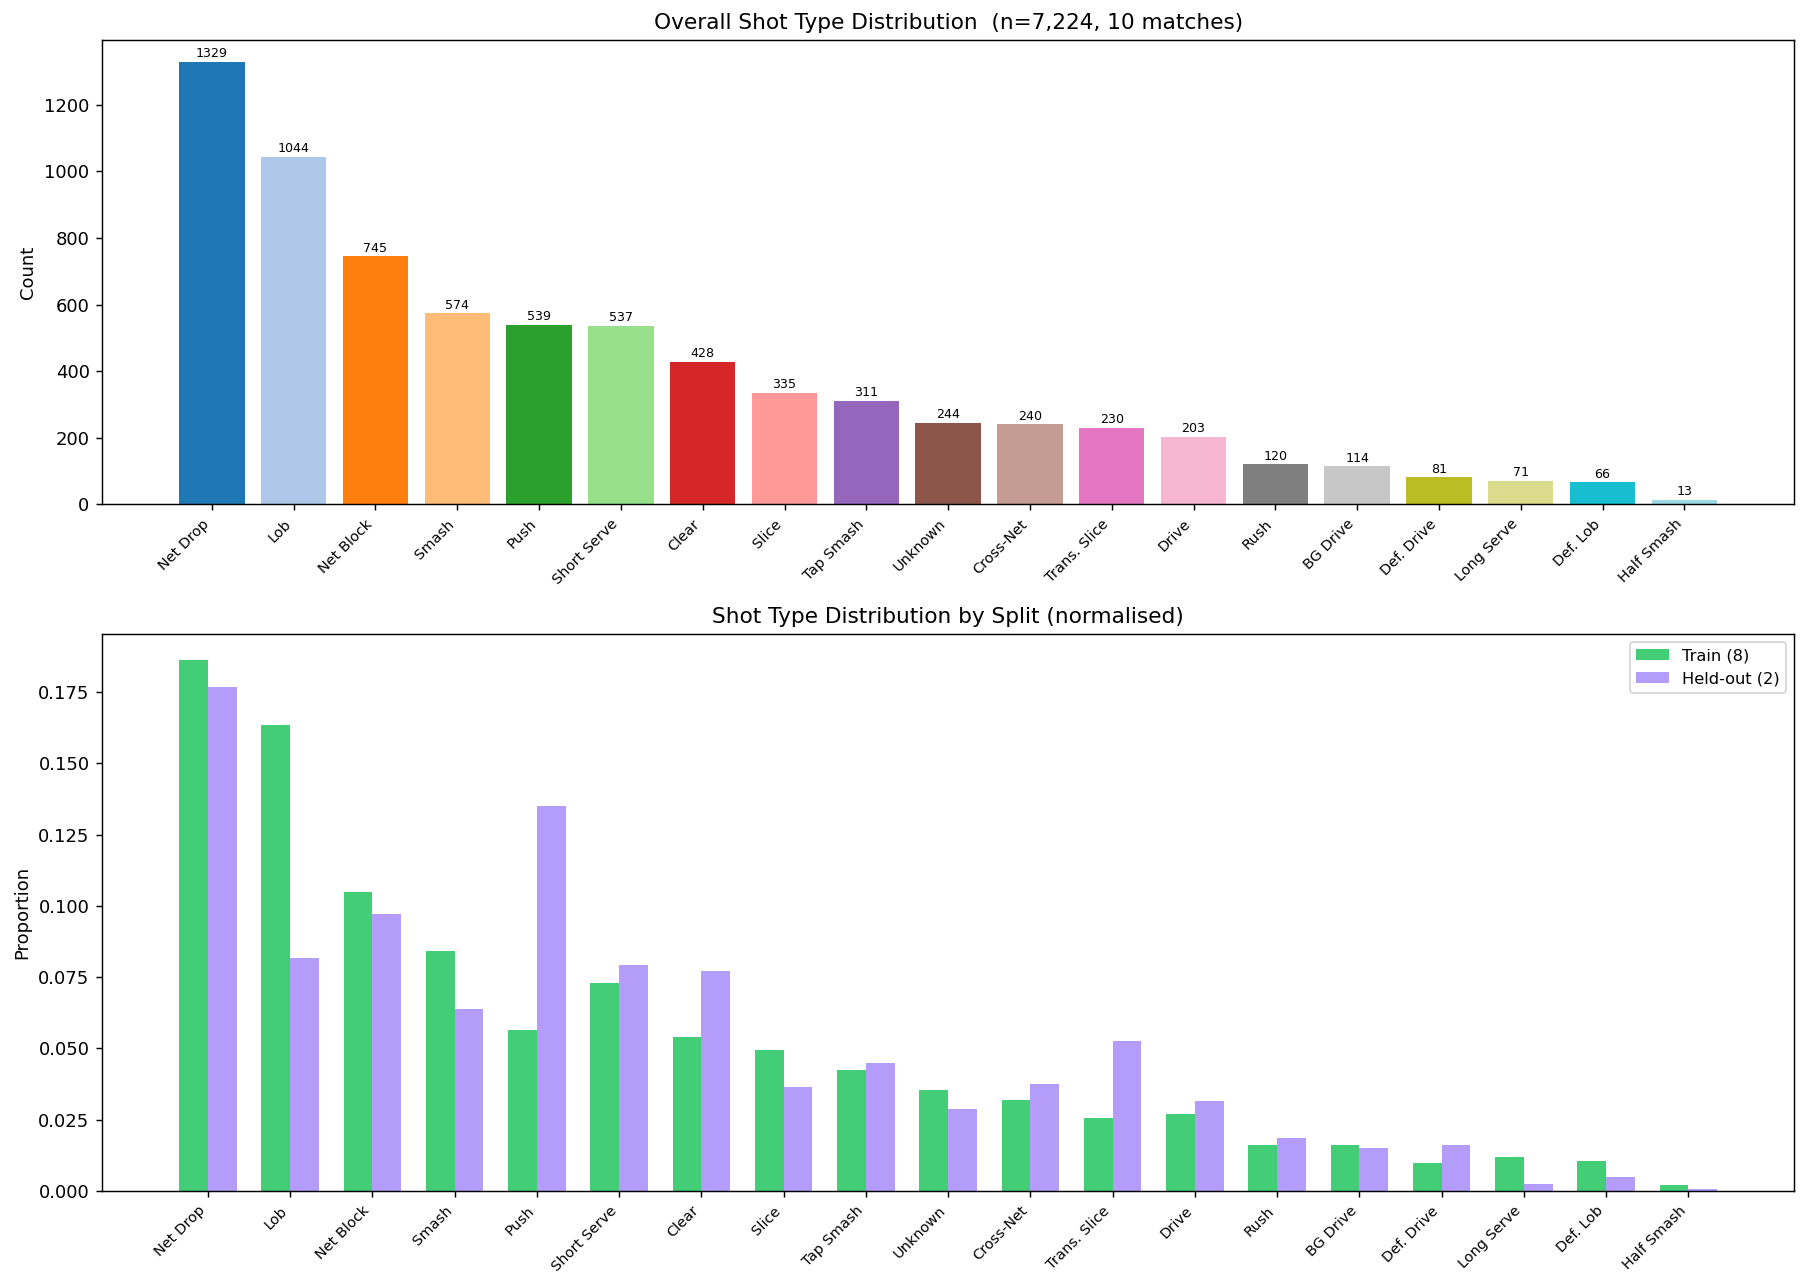

Imbalance ratio (max/min): 102.2×

Top-5 shot types:
         Net Drop:  1329  (18.4%)
              Lob:  1044  (14.5%)
        Net Block:   745  (10.3%)
            Smash:   574  (7.9%)
             Push:   539  (7.5%)


In [3]:
type_counts = strokes['type'].value_counts()
en_labels = [SHOT_TYPE_EN.get(s, s) for s in type_counts.index]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 1.2]})

# Overall distribution
colors = plt.cm.tab20(np.linspace(0, 1, len(type_counts)))
bars = axes[0].bar(range(len(type_counts)), type_counts.values, color=colors)
axes[0].set_xticks(range(len(type_counts)))
axes[0].set_xticklabels(en_labels, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Count')
axes[0].set_title(f'Overall Shot Type Distribution  (n={len(strokes):,}, 10 matches)')
for bar, cnt in zip(bars, type_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(cnt), ha='center', va='bottom', fontsize=7)

# Per-split (grouped bar)
split_type = strokes.groupby(['split', 'type']).size().unstack(fill_value=0)
split_type = split_type.reindex(index=['train', 'held_out'], columns=type_counts.index, fill_value=0)
# Normalise within each split
split_pct = split_type.div(split_type.sum(axis=1), axis=0)

x = np.arange(len(type_counts))
w = 0.35
for i, sp in enumerate(['train', 'held_out']):
    axes[1].bar(x + i*w - w/2, split_pct.loc[sp].values, w,
                label=SPLIT_LABELS[sp], color=SPLIT_COLORS[sp], alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(en_labels, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Proportion')
axes[1].set_title('Shot Type Distribution by Split (normalised)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Print top-5 imbalance
print(f"Imbalance ratio (max/min): {type_counts.max() / type_counts.min():.1f}×")
print(f"\nTop-5 shot types:")
for shot, cnt in type_counts.head(5).items():
    print(f"  {SHOT_TYPE_EN.get(shot, shot):>15}: {cnt:>5}  ({cnt/len(strokes)*100:.1f}%)")

## 4. Per-Match Shot Counts (stacked by shot type)

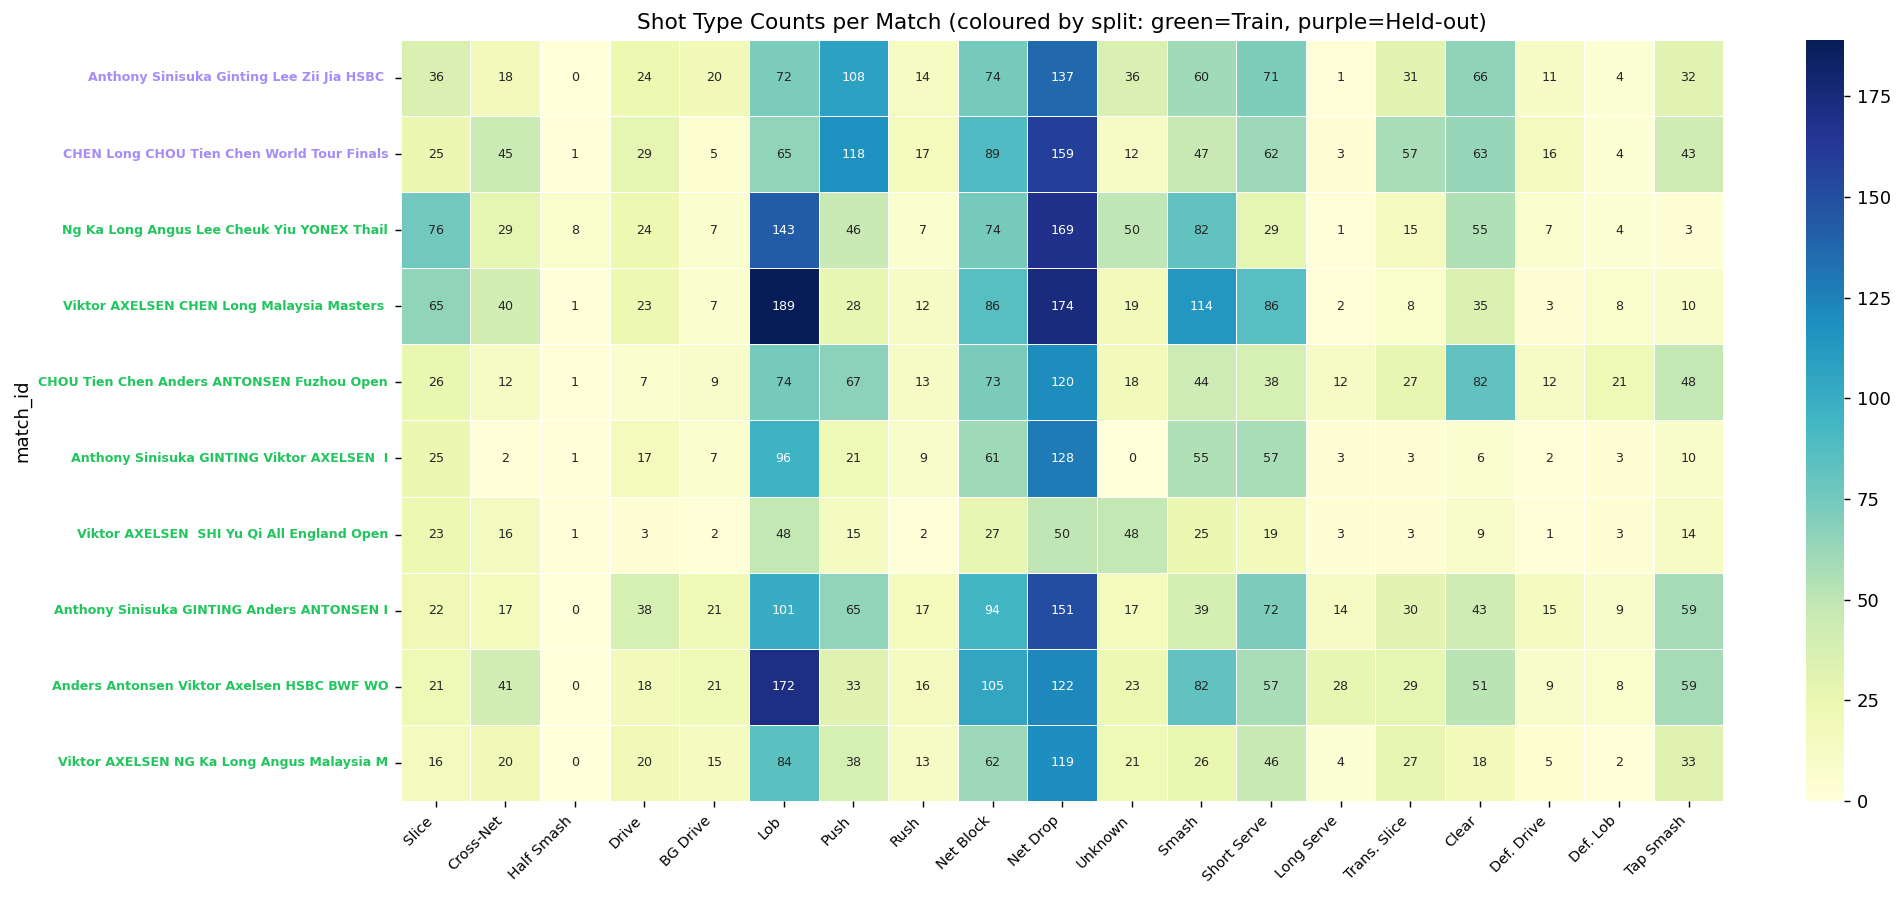

In [4]:
# Shot type heatmap per match
spm = strokes.groupby(['match_id', 'type']).size().unstack(fill_value=0)
spm.columns = [SHOT_TYPE_EN.get(c, c) for c in spm.columns]

# Add split label to index
split_map = strokes.groupby('match_id')['split'].first()
spm['_split'] = spm.index.map(split_map)
spm = spm.sort_values(['_split', spm.columns[0]], ascending=[True, False])
split_labels = spm['_split'].values
spm = spm.drop(columns='_split')

# Colour row labels by split
row_labels = [m.replace('_', ' ')[:42] for m in spm.index]
row_colors = [SPLIT_COLORS.get(s, '#888') for s in split_labels]

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(spm, annot=True, fmt='d', cmap='YlGnBu',
            ax=ax, linewidths=0.3, annot_kws={'size': 7})
ax.set_yticklabels(row_labels, fontsize=7)
for i, (label, color) in enumerate(zip(ax.get_yticklabels(), row_colors)):
    label.set_color(color)
    label.set_fontweight('bold')
ax.set_title('Shot Type Counts per Match (coloured by split: green=Train, purple=Held-out)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

## 5. Rally Length Distribution

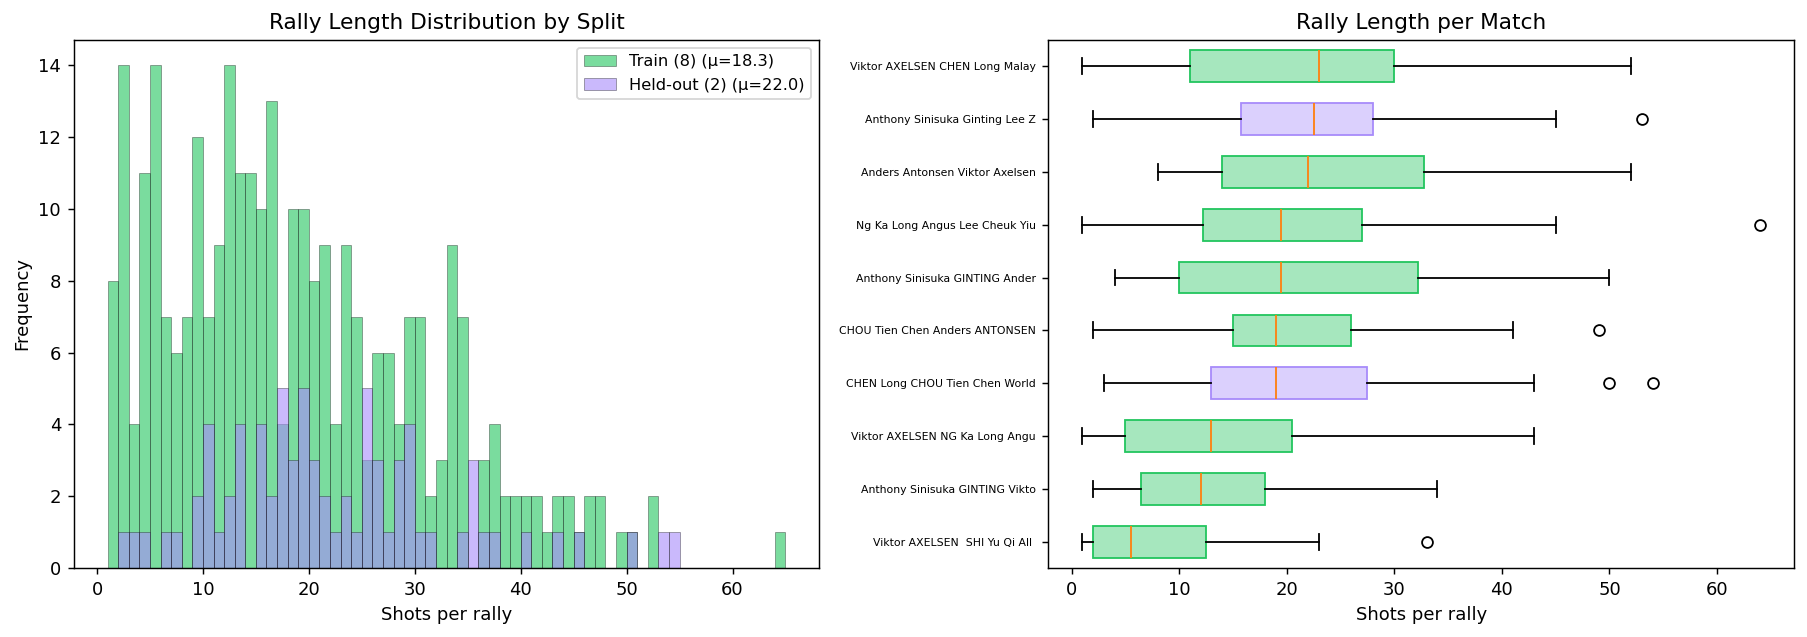

Total rallies: 379
Shots/rally — min: 1, median: 17, mean: 19.1, max: 64


In [5]:
rally_len = strokes.groupby(['split', 'match_id', 'rally']).size().reset_index(name='n_shots')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram per split
for sp in ('train', 'held_out'):
    sub = rally_len[rally_len['split'] == sp]
    axes[0].hist(sub['n_shots'], bins=range(1, rally_len['n_shots'].max() + 2),
                 alpha=0.6, label=f"{SPLIT_LABELS[sp]} (μ={sub['n_shots'].mean():.1f})",
                 color=SPLIT_COLORS[sp], edgecolor='black', linewidth=0.3)
axes[0].set_xlabel('Shots per rally')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Rally Length Distribution by Split')
axes[0].legend(fontsize=9)

# Box plot per match
match_order = rally_len.groupby('match_id')['n_shots'].median().sort_values().index
bp = axes[1].boxplot(
    [rally_len[rally_len['match_id'] == m]['n_shots'].values for m in match_order],
    vert=False, patch_artist=True, widths=0.6
)
# Colour boxes by split
for i, m in enumerate(match_order):
    sp = active_matches[m]
    bp['boxes'][i].set_facecolor(SPLIT_COLORS[sp] + '66')
    bp['boxes'][i].set_edgecolor(SPLIT_COLORS[sp])
axes[1].set_yticklabels([m.replace('_', ' ')[:30] for m in match_order], fontsize=6)
axes[1].set_xlabel('Shots per rally')
axes[1].set_title('Rally Length per Match')

plt.tight_layout()
plt.show()

print(f"Total rallies: {len(rally_len)}")
print(f"Shots/rally — min: {rally_len['n_shots'].min()}, "
      f"median: {rally_len['n_shots'].median():.0f}, "
      f"mean: {rally_len['n_shots'].mean():.1f}, "
      f"max: {rally_len['n_shots'].max()}")

## 6. Shot Transition Matrix

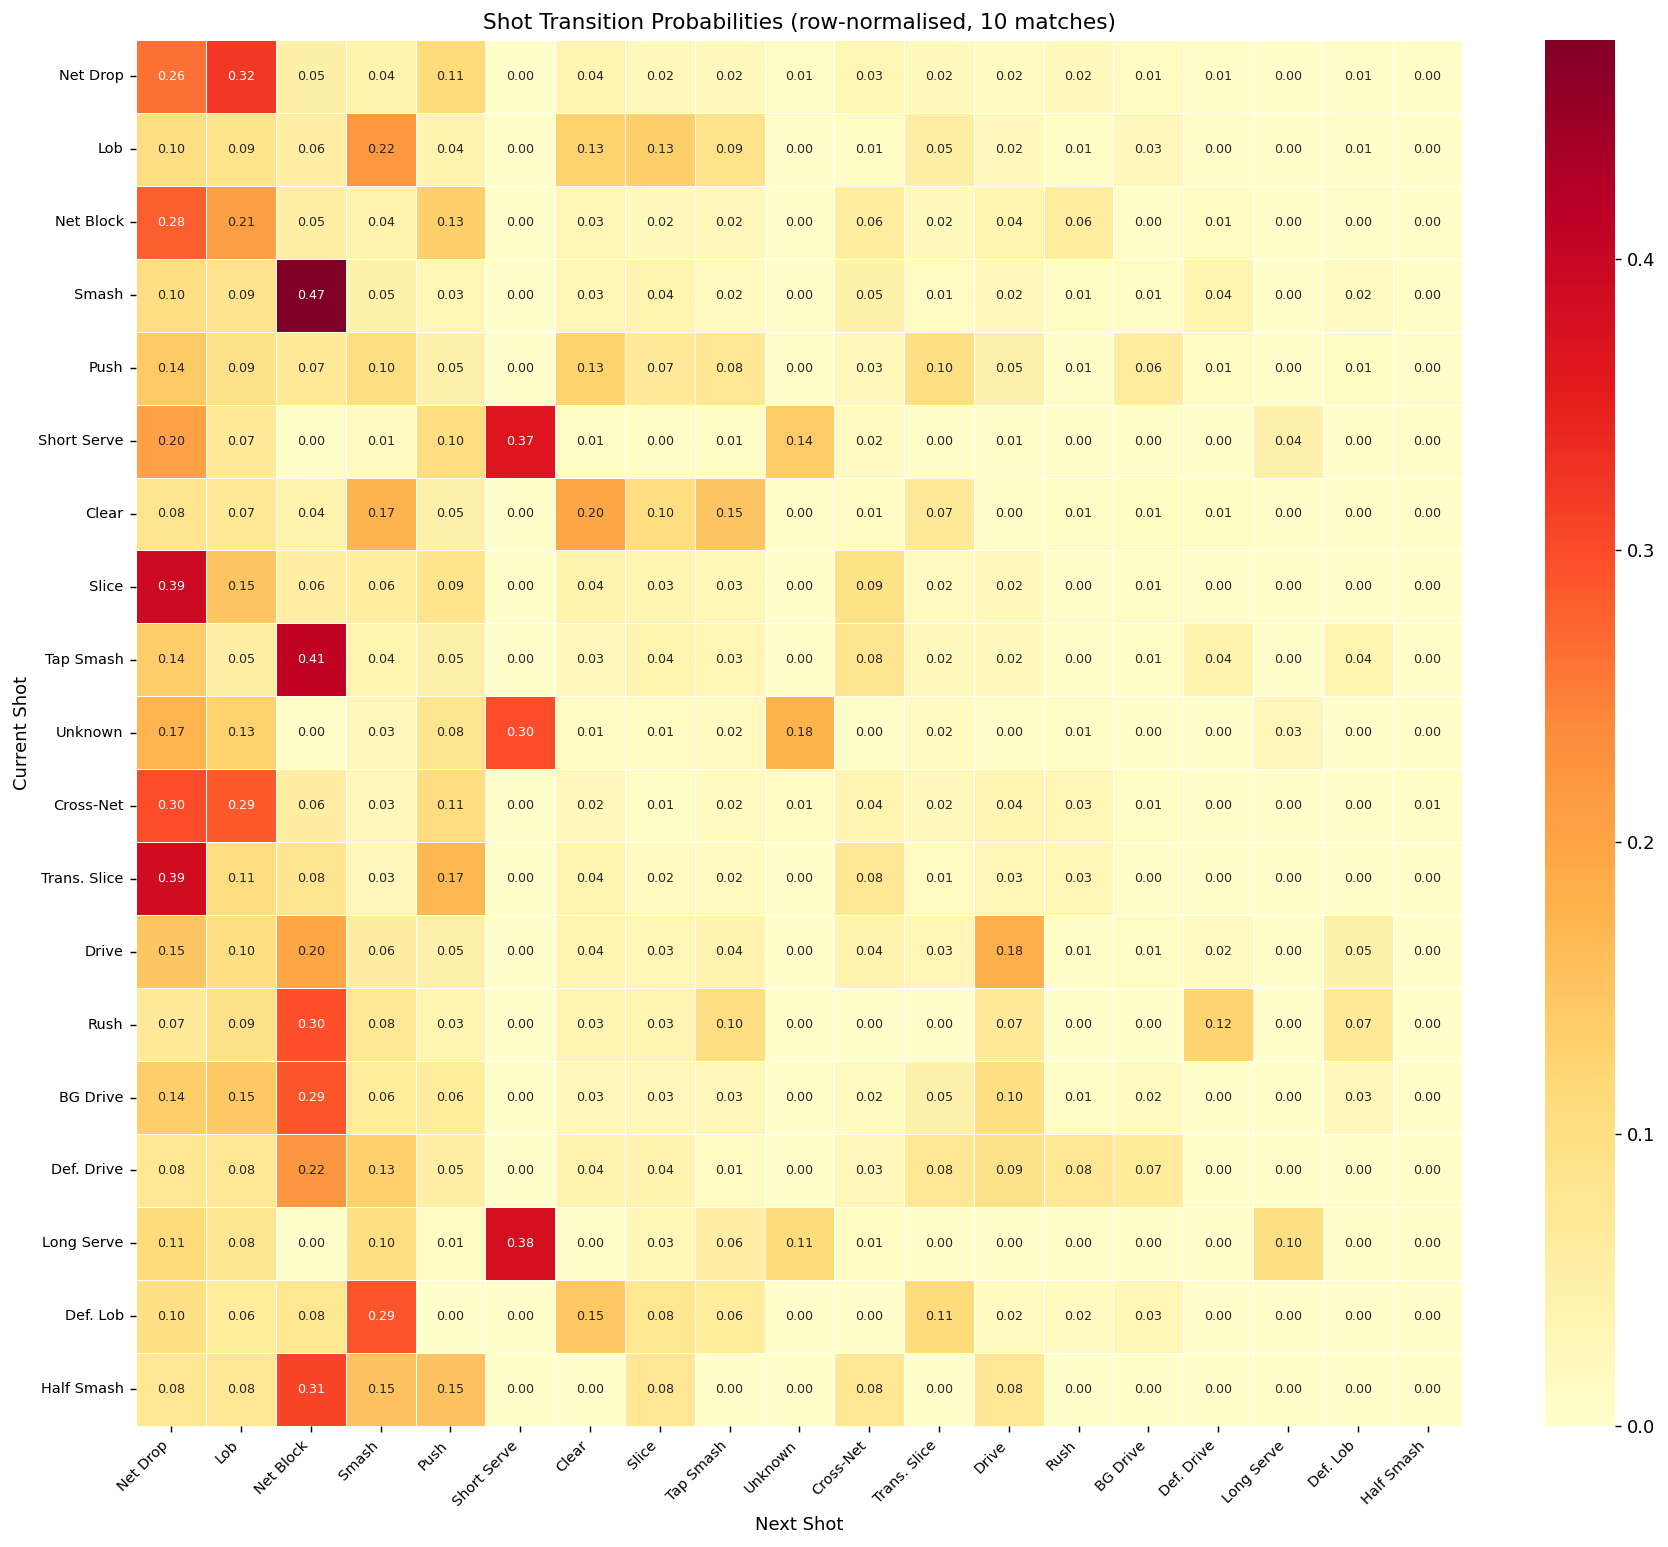

In [6]:
transitions = Counter()
for (match_id, rally), grp in strokes.groupby(['match_id', 'rally']):
    shots = grp.sort_values('ball_round')['type'].tolist()
    for a, b in zip(shots, shots[1:]):
        transitions[(a, b)] += 1

all_types = type_counts.index.tolist()
trans_mat = pd.DataFrame(0, index=all_types, columns=all_types)
for (a, b), cnt in transitions.items():
    if a in trans_mat.index and b in trans_mat.columns:
        trans_mat.loc[a, b] = cnt
trans_prob = trans_mat.div(trans_mat.sum(axis=1), axis=0).fillna(0)

en_idx = [SHOT_TYPE_EN.get(s, s) for s in all_types]
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(trans_prob, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=en_idx, yticklabels=en_idx,
            ax=ax, linewidths=0.3, annot_kws={'size': 7})
ax.set_xlabel('Next Shot')
ax.set_ylabel('Current Shot')
ax.set_title('Shot Transition Probabilities (row-normalised, 10 matches)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Court Position Heatmaps

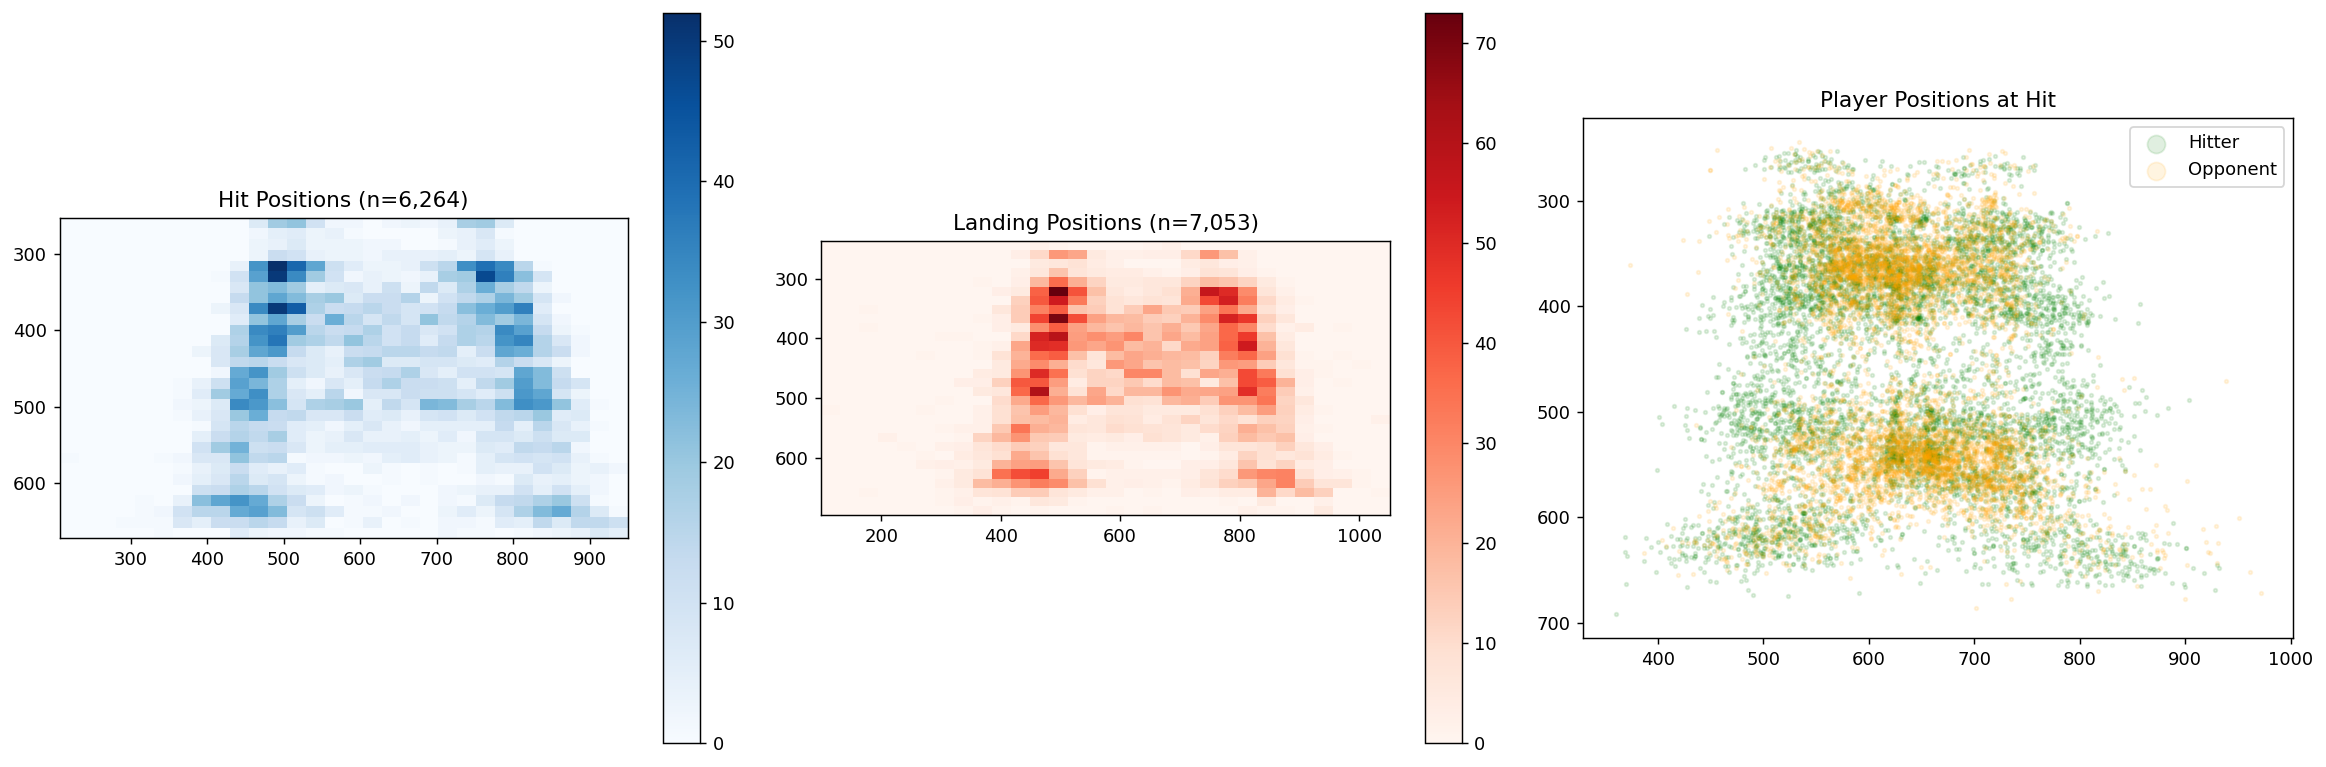

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

def heatmap2d(ax, x, y, title, cmap):
    mask = x.notna() & y.notna()
    if mask.sum() > 0:
        h = ax.hist2d(x[mask], y[mask], bins=30, cmap=cmap)
        plt.colorbar(h[3], ax=ax)
    ax.set_title(f'{title} (n={mask.sum():,})')
    ax.invert_yaxis(); ax.set_aspect('equal')

heatmap2d(axes[0], strokes['hit_x'],     strokes['hit_y'],     'Hit Positions',     'Blues')
heatmap2d(axes[1], strokes['landing_x'], strokes['landing_y'], 'Landing Positions', 'Reds')

# Player vs opponent positions
pm = strokes['player_location_x'].notna()
om = strokes['opponent_location_x'].notna()
axes[2].scatter(strokes.loc[pm, 'player_location_x'], strokes.loc[pm, 'player_location_y'],
                alpha=0.12, s=4, c='green', label='Hitter')
axes[2].scatter(strokes.loc[om, 'opponent_location_x'], strokes.loc[om, 'opponent_location_y'],
                alpha=0.12, s=4, c='orange', label='Opponent')
axes[2].set_title('Player Positions at Hit')
axes[2].invert_yaxis(); axes[2].set_aspect('equal')
axes[2].legend(markerscale=5)

plt.tight_layout()
plt.show()

## 8. Skeleton & Shuttle Data Coverage

In [8]:
# Check GDINO skeleton and shuttle coverage for each match
coverage = []
for match_id, sp in sorted(active_matches.items()):
    gdino_dir = SS_SKELETONS_GDINO / match_id
    has_gdino = (gdino_dir / 'skeletons.npy').exists()
    gdino_frames = 0
    if has_gdino:
        fn = np.load(gdino_dir / 'frame_nums.npy')
        gdino_frames = len(fn)

    # Shuttle: whole-match or per-rally
    shuttle_path = SS_SHUTTLES / f'{match_id}.npy'
    if shuttle_path.exists():
        sh = np.load(shuttle_path)
        shuttle_shots = int((sh[:, 3] > 0).sum()) if sh.shape[1] == 4 else int((sh[:, 2] > 0).sum())
    else:
        shuttle_shots = 0
        for fp in sorted(SS_SHUTTLES.glob(f'{match_id}_s*r*.npy')):
            if fp.stem.endswith('_frames'):
                continue
            coords = np.load(fp)
            shuttle_shots += int((coords[:, 2] > 0).sum())

    n_shots = len(strokes[strokes['match_id'] == match_id])
    coverage.append({
        'match': match_id.replace('_', ' ')[:42],
        'split': sp,
        'shots': n_shots,
        'gdino': 'Yes' if has_gdino else 'No',
        'skel_frames': gdino_frames,
        'shuttle_hits': shuttle_shots,
        'shuttle_pct': f"{shuttle_shots/n_shots*100:.0f}%" if n_shots > 0 else '0%',
    })

cov_df = pd.DataFrame(coverage)
print(cov_df.to_string(index=False))

# Summary
total_gdino = sum(1 for c in coverage if c['gdino'] == 'Yes')
total_shuttle = sum(c['shuttle_hits'] for c in coverage)
total_shots = sum(c['shots'] for c in coverage)
print(f"\nGDINO skeletons: {total_gdino}/{len(coverage)} matches")
print(f"Shuttle coverage: {total_shuttle}/{total_shots} shots ({total_shuttle/total_shots*100:.1f}%)")

                                     match    split  shots gdino  skel_frames  shuttle_hits shuttle_pct
Anders Antonsen Viktor Axelsen HSBC BWF WO    train    895   Yes         6715          4298        480%
Anthony Sinisuka GINTING Anders ANTONSEN I    train    824   Yes         5347           457         55%
Anthony Sinisuka GINTING Viktor AXELSEN  I    train    506   Yes         3307           282         56%
Anthony Sinisuka Ginting Lee Zii Jia HSBC  held_out    815   Yes         6269          4292        527%
CHEN Long CHOU Tien Chen World Tour Finals held_out    860   Yes         5699           489         57%
CHOU Tien Chen Anders ANTONSEN Fuzhou Open    train    704   Yes         4745          3438        488%
Ng Ka Long Angus Lee Cheuk Yiu YONEX Thail    train    829   Yes         6344          4643        560%
Viktor AXELSEN  SHI Yu Qi All England Open    train    312   Yes         2142          1311        420%
Viktor AXELSEN CHEN Long Malaysia Masters     train    910   Yes

## 9. Shot Type Balance Across Splits (KL Divergence)

KL Divergence (lower = more balanced):
  KL(train || held_out) = 0.0960


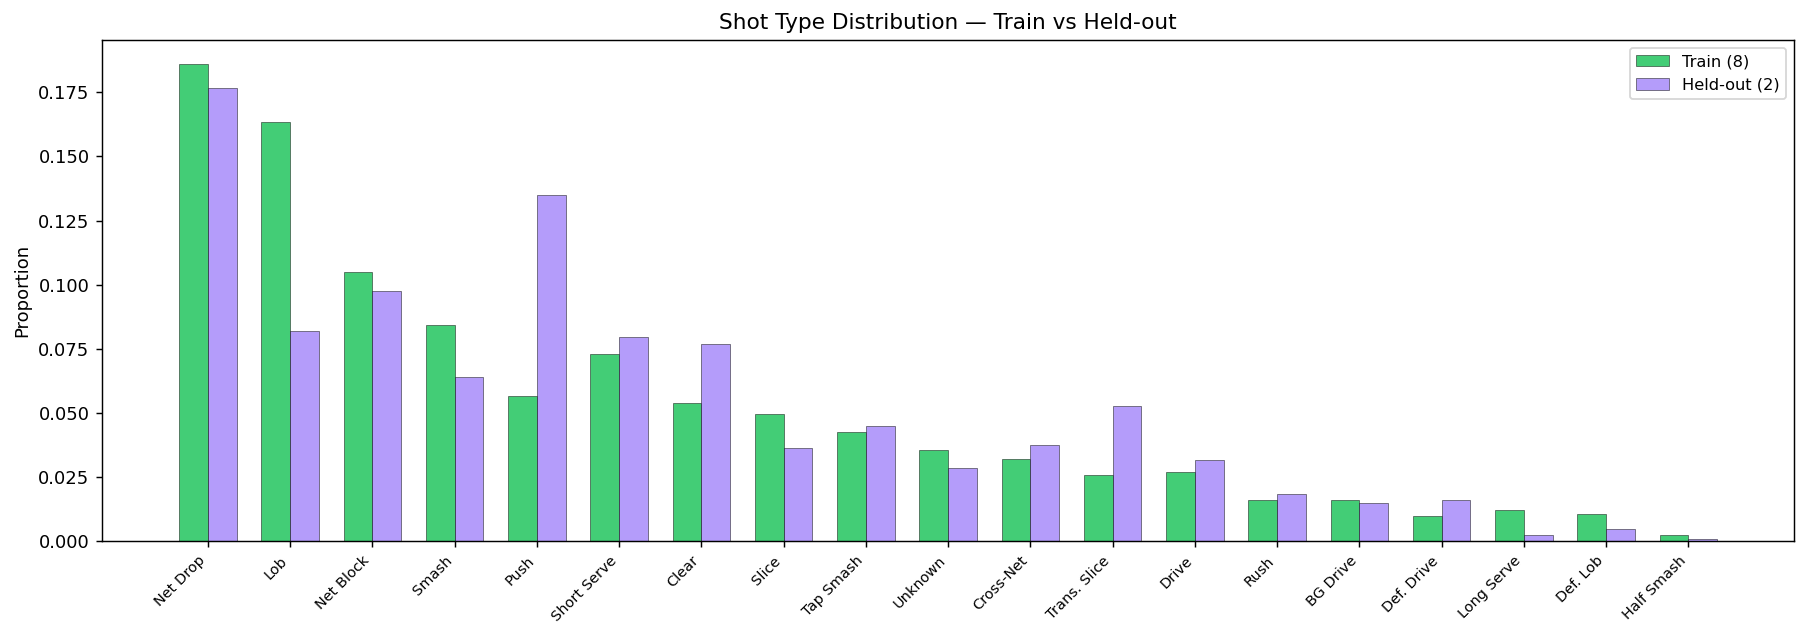

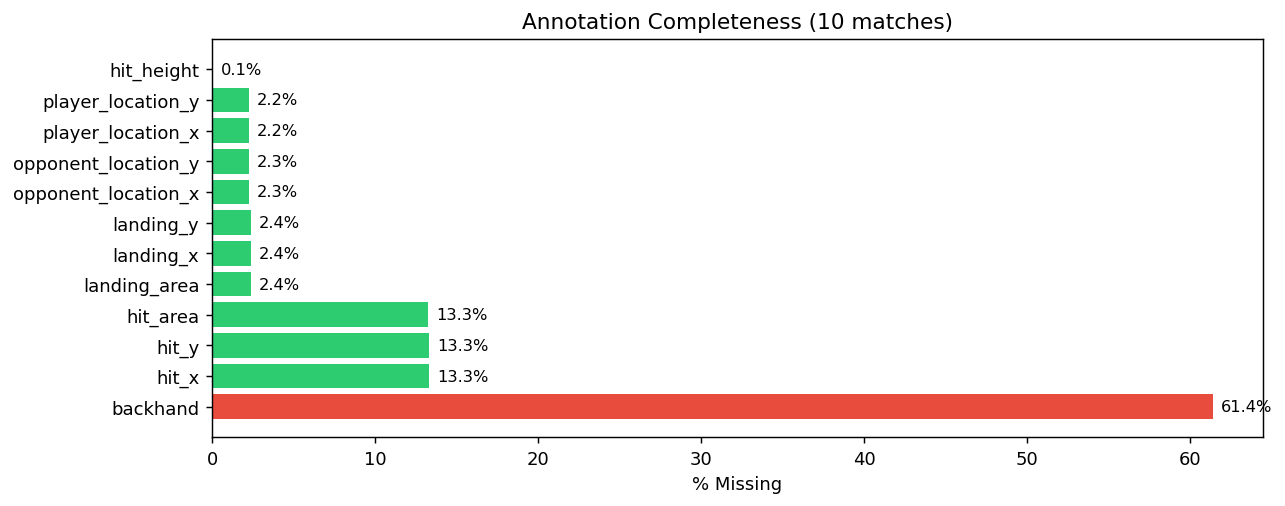

In [9]:
# KL divergence between train and held_out
eps = 1e-9
split_dist = {}
for sp in ('train', 'held_out'):
    vec = split_type.loc[sp].values.astype(float)
    split_dist[sp] = vec / vec.sum()

p, q = split_dist['train'], split_dist['held_out']
kl = (p * np.log((p + eps) / (q + eps))).sum()
print(f"KL Divergence (lower = more balanced):")
print(f"  KL(train || held_out) = {kl:.4f}")

# Visual comparison
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(type_counts))
w = 0.35
for i, sp in enumerate(['train', 'held_out']):
    ax.bar(x + i*w - w/2, split_dist[sp], w,
           label=SPLIT_LABELS[sp], color=SPLIT_COLORS[sp], alpha=0.85, edgecolor='black', linewidth=0.3)
ax.set_xticks(x)
ax.set_xticklabels(en_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Proportion')
ax.set_title('Shot Type Distribution — Train vs Held-out')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Annotation completeness
feat_cols = ['hit_area', 'hit_x', 'hit_y', 'landing_area', 'landing_x', 'landing_y',
             'player_location_x', 'player_location_y',
             'opponent_location_x', 'opponent_location_y',
             'backhand', 'hit_height']
available = [c for c in feat_cols if c in strokes.columns]
miss_pct = (strokes[available].isna().mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if p > 50 else '#e67e22' if p > 20 else '#2ecc71' for p in miss_pct]
ax.barh(miss_pct.index, miss_pct.values, color=colors)
ax.set_xlabel('% Missing')
ax.set_title('Annotation Completeness (10 matches)')
for i, (col, pct) in enumerate(miss_pct.items()):
    ax.text(pct + 0.5, i, f'{pct:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 10. Player & Tournament Breakdown

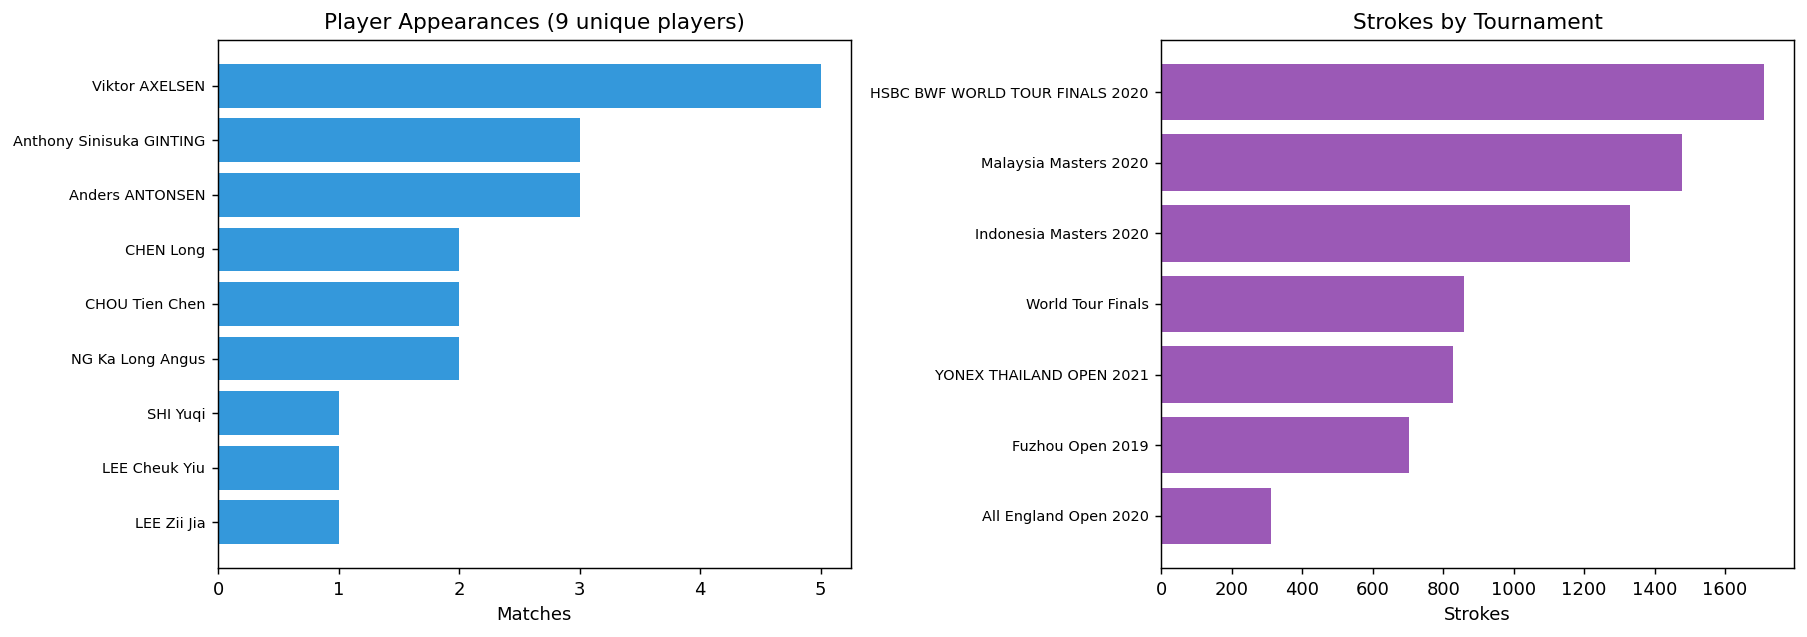

Unique players: 9
Unique tournaments: 7

Player appearances:
  Viktor AXELSEN: 5 matches
  Anthony Sinisuka GINTING: 3 matches
  Anders ANTONSEN: 3 matches
  CHEN Long: 2 matches
  CHOU Tien Chen: 2 matches
  NG Ka Long Angus: 2 matches
  SHI Yuqi: 1 match
  LEE Cheuk Yiu: 1 match
  LEE Zii Jia: 1 match


In [10]:
# Player frequency
strokes_meta = strokes.merge(match_meta[['video', 'tournament', 'round', 'year', 'winner', 'loser']],
                              left_on='match_id', right_on='video', how='left')

all_players = pd.concat([match_meta['winner'], match_meta['loser']]).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Player appearances
axes[0].barh(range(len(all_players)), all_players.values, color='#3498db')
axes[0].set_yticks(range(len(all_players)))
axes[0].set_yticklabels(all_players.index, fontsize=8)
axes[0].set_xlabel('Matches')
axes[0].set_title(f'Player Appearances ({len(all_players)} unique players)')
axes[0].invert_yaxis()

# Tournament
tourn = strokes_meta['tournament'].value_counts()
axes[1].barh(range(len(tourn)), tourn.values, color='#9b59b6')
axes[1].set_yticks(range(len(tourn)))
axes[1].set_yticklabels(tourn.index, fontsize=8)
axes[1].set_xlabel('Strokes')
axes[1].set_title('Strokes by Tournament')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Unique players: {len(all_players)}")
print(f"Unique tournaments: {tourn.shape[0]}")
print(f"\nPlayer appearances:")
for p, c in all_players.items():
    print(f"  {p}: {c} match{'es' if c > 1 else ''}")

## Summary

In [ ]:
# Recompute split_summary in case of kernel state issues
split_summary = strokes.groupby('split').agg(
    matches=('match_id', 'nunique'),
    rallies=('rally', 'nunique'),
    shots=('type', 'count'),
    shot_types=('type', 'nunique'),
).reindex(['train', 'held_out'])
split_summary['shots_pct'] = (split_summary['shots'] / split_summary['shots'].sum() * 100).round(1)

type_counts = strokes['type'].value_counts()
all_players = pd.concat([match_meta['winner'], match_meta['loser']]).value_counts()

total_gdino = 0
total_shuttle = 0
total_shots = len(strokes)
for match_id, sp in active_matches.items():
    gdino_dir = SS_SKELETONS_GDINO / match_id
    if (gdino_dir / 'skeletons.npy').exists():
        total_gdino += 1
    shuttle_path = SS_SHUTTLES / f'{match_id}.npy'
    if shuttle_path.exists():
        sh = np.load(shuttle_path)
        total_shuttle += int((sh[:, 3] > 0).sum()) if sh.shape[1] == 4 else int((sh[:, 2] > 0).sum())
    else:
        for fp in sorted(SS_SHUTTLES.glob(f'{match_id}_s*r*.npy')):
            if fp.stem.endswith('_frames'): continue
            coords = np.load(fp)
            total_shuttle += int((coords[:, 2] > 0).sum())

rally_len = strokes.groupby(['split', 'match_id', 'rally']).size().reset_index(name='n_shots')

print("=" * 65)
print("10-MATCH SPLIT EDA SUMMARY")
print("=" * 65)
print(f"Total matches         : {len(active_matches)}")
for sp in ('train', 'held_out'):
    n = split_summary.loc[sp]
    print(f"  {sp:10s}: {int(n['matches'])} matches, {int(n['shots']):,} shots ({n['shots_pct']}%)")
print(f"Total strokes         : {len(strokes):,}")
print(f"Total rallies         : {len(rally_len):,}")
print(f"Unique shot types     : {strokes['type'].nunique()}")
print(f"Avg shots/rally       : {rally_len['n_shots'].mean():.1f}")
print(f"Imbalance ratio       : {type_counts.max()/type_counts.min():.0f}x")
print(f"GDINO skeletons       : {total_gdino}/{len(active_matches)} matches")
print(f"Shuttle coverage      : {total_shuttle}/{total_shots} shots ({total_shuttle/total_shots*100:.1f}%)")
print(f"Unique players        : {len(all_players)}")
print("=" * 65)

## Insights & Implications for Modelling

### 1. Severe Class Imbalance (102x ratio)
The most frequent shot type (**Net Drop**, 18.4%) has **102x** more samples than the rarest (**Unknown**, <0.2%). The top-5 types (Net Drop, Lob, Net Block, Smash, Push) account for ~58% of all shots, while the bottom-5 (Trans. Slice, BG Drive, Half Smash, Def. Drive, Unknown) together make up <5%.

**Implication:** A naive cross-entropy loss will be dominated by frequent types. Consider:
- Weighted cross-entropy or focal loss with class-frequency-based weights
- Grouping the rarest types (Trans. Slice, BG Drive, Half Smash, Unknown) into a single "Other" class to reduce the 19-class problem to ~15 meaningful classes
- Stratified sampling during cross-validation to ensure rare types appear in each fold

### 2. Train/Held-out Split is Reasonably Balanced (KL = 0.096)
The KL divergence of 0.096 between train and held-out shot distributions is low, meaning the 2 held-out matches have a similar shot mix to the 8 training matches. Both splits contain all 19 shot types.

**Caveat:** The held-out split has only 2 matches (23.2% of shots). With so few matches, held-out performance is sensitive to match-specific playing styles. Cross-validation on the 8 train matches is more reliable for model selection.

### 3. Long and Variable Rallies (median=17, max=64)
Rallies average 19.1 shots with high variance (1 to 64). This has direct implications for temporal modelling:
- Sequence models (ST-GCN, LSTM) need to handle variable-length inputs up to ~64 time steps
- Very short rallies (1-3 shots) are mostly serves, providing little temporal context
- Consider a minimum rally length threshold (e.g., >= 3 shots) to filter trivial sequences

### 4. Match-Level Heterogeneity
Shot counts per match range from 312 (Axelsen vs Shi Yu Qi) to 910 (Axelsen vs Chen Long) -- a 3x difference. The smallest match contributes only 4.3% of training data.

**Implication:** Match-level leave-one-out cross-validation folds will have very different sizes. Weight evaluation metrics accordingly, or use stratified rally-level splitting within cross-validation.

### 5. Strong Shot Transition Patterns
The transition matrix reveals predictable sequences:
- **Serves** (Short/Long) almost always transition to **Push**, **Lob**, or **Net Block** -- these are return-of-serve patterns
- **Smash** is most often followed by **Def. Lob** or **Def. Drive** (defensive returns)
- **Net Drop** frequently leads to **Lob** or **Net Block** (net-play exchanges)

**Implication:** A temporal model should capture these bigram dependencies. The transition structure also suggests that **shot context** (previous 2-3 shots) is highly informative -- a feature the ST-GCN can leverage through its temporal convolutions.

### 6. Court Position Clustering
Hit positions cluster strongly around mid-court and net areas, while landing positions spread more evenly. Players tend to occupy base positions near centre-court between shots.

**Implication:** Court position features (hit_x/y, landing_x/y, player/opponent location) are informative but redundant with skeleton pose data. If using skeleton-based models, court position may add marginal value as auxiliary features.

### 7. Full GDINO Skeleton Coverage
All 10 matches have GDINO-extracted skeletons (100% coverage), which is a clean starting point for skeleton-based modelling. No missing skeleton data to handle.

### 8. Shuttle Coverage Anomaly (362.9%)
Shuttle coverage exceeds 100% for most matches, indicating the shuttle trajectory data contains per-frame detections (not per-shot). The raw `.npy` files store frame-level `[frame, x, y, visibility]` tuples. This is actually **useful** -- it provides dense trajectory features between shots, not just at hit frames.

### 9. Player Diversity Risk
Viktor Axelsen appears in **5 of 10 matches** (50%). The model risks learning Axelsen-specific movement patterns rather than generalising to unseen players.

**Mitigation:** During cross-validation, ensure at least one fold where all Axelsen matches are in validation. Monitor per-player performance to detect overfitting to frequent players.

### 10. Annotation Completeness
Key features like `hit_x`, `hit_y`, `landing_x`, `landing_y` have low missingness, but `backhand` and `hit_height` have higher missing rates. These features may need imputation or should be treated as optional model inputs.